<a href="https://www.kaggle.com/code/ayxanbeydiyev/wildfire-cnn?scriptVersionId=342369779" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
'''
Imports and configuration
'''

import os, shutil, pathlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix

# Config constants
IMG_SIZE = 256
BATCH_SIZE = 32
SEED = 42

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

In [35]:
root = pathlib.Path("/kaggle/input/datasets/abdelghaniaaba/wildfire-prediction-dataset")
if not (root / "train").exists():
    root = next(p for p in root.iterdir() if p.is_dir())

# Scan for images that fail to decode
bad_files = set()
for path in root.rglob("*.jpg"):
    try:
        with Image.open(path) as img:
            img.load()
    except Exception:
        bad_files.add(path)

print(f"Found {len(bad_files)} corrupt file(s); they'll be excluded when building the datasets")

class_names = sorted(d.name for d in (root / "train").iterdir() if d.is_dir())
print("Classes:", class_names)

Found 2 corrupt file(s); they'll be excluded when building the datasets
Classes: ['nowildfire', 'wildfire']


In [36]:
'''
Build datasets
'''

def load_and_preprocess(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    label = tf.reshape(tf.cast(label, tf.float32), [1])
    return img, label

def make_dataset(split_dir, shuffle):
    paths, labels = [], []
    for label_idx, cname in enumerate(class_names):
        # Iterate over all jpg files
        for p in sorted((split_dir / cname).glob("*.jpg")):
            # if this file is not corrupt, load it later.
            if p not in bad_files:
                paths.append(str(p))
                labels.append(label_idx)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE)

train_ds = make_dataset(root / "train", shuffle=True)
val_ds = make_dataset(root / "valid", shuffle=True)
test_ds = make_dataset(root / "test", shuffle=False)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

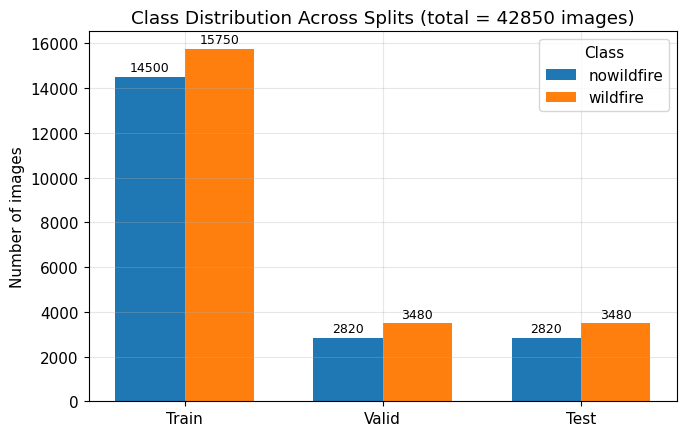

In [37]:
'''
Exploratory data analysis
'''

# Image counts per class, per split
def class_counts(split_dir):
    return {c: len(list((split_dir / c).glob("*.jpg"))) for c in class_names}

counts = {
    "train": class_counts(root / "train"),
    "valid": class_counts(root / "valid"),
    "test": class_counts(root / "test"),
}

splits = list(counts.keys())
x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, cname in enumerate(class_names):
    values = [counts[s][cname] for s in splits]
    bars = ax.bar(x + (i - 0.5) * width, values, width, label=cname)
    ax.bar_label(bars, padding=2, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in splits])
ax.set_ylabel("Number of images")
total_images = sum(sum(counts[s].values()) for s in splits)
ax.set_title(f"Class Distribution Across Splits (total = {total_images} images)")
ax.legend(title="Class")
fig.tight_layout()
plt.show()

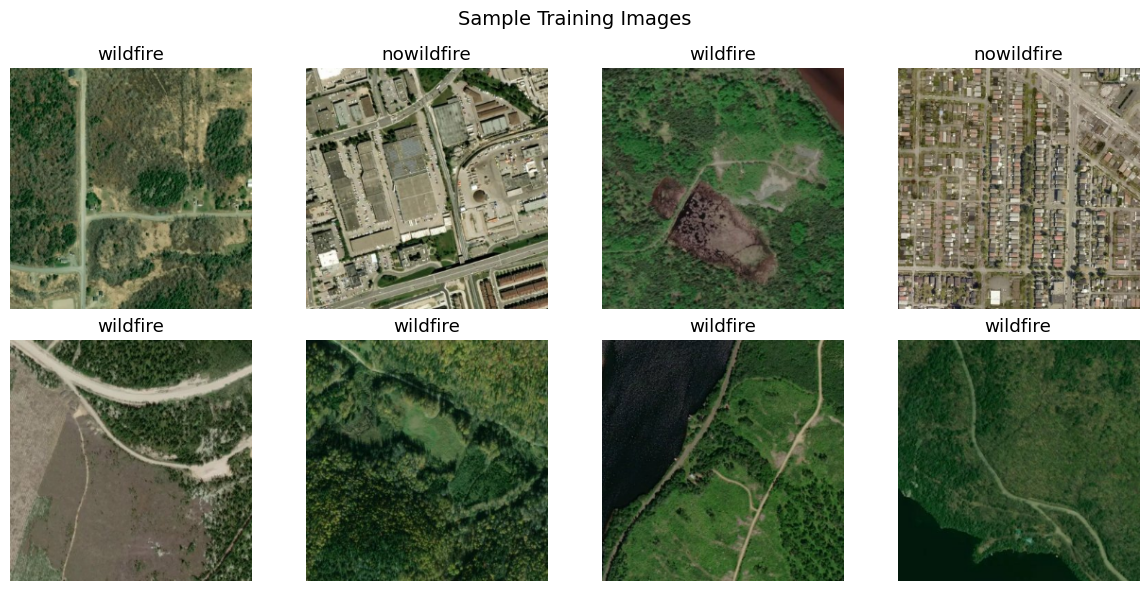

In [38]:
# Example images with their true labels
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 6))
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i].numpy()[0])])
        plt.axis("off")
    plt.suptitle("Sample Training Images", fontsize=14)
    plt.tight_layout()
    plt.show()

In [39]:
train_counts = counts["train"]
total = sum(train_counts.values())
class_weight = {i: total / (2 * train_counts[name]) for i, name in enumerate(class_names)}
print("Class weights:", {class_names[i]: round(w, 3) for i, w in class_weight.items()})

Class weights: {'nowildfire': 1.043, 'wildfire': 0.96}


In [40]:
model = tf.keras.Sequential([
    tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),

    # Augmentation
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.Rescaling(1.0 / 255),

    # Conv block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", kernel_regularizer=l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Conv block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", kernel_regularizer=l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Conv block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", kernel_regularizer=l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Conv block 4
    tf.keras.layers.Conv2D(256, (3, 3), activation="relu", kernel_regularizer=l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification head
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=l2(1e-4)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 256, 256, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 256, 256, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [41]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
]

In [ ]:
'''
Training
'''

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight,
)

print(f"{len(history.history['accuracy'])} epochs recorded")

Epoch 1/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 167s 172ms/step - accuracy: 0.9111 - loss: 0.2779 - precision: 0.9076 - recall: 0.9233 - val_accuracy: 0.7557 - val_loss: 0.9696 - val_precision: 0.6939 - val_recall: 0.9980 - learning_rate: 0.0010
Epoch 2/10
 84/946 ━━━━━━━━━━━━━━━━━━━━ 2:19 162ms/step - accuracy: 0.9222 - loss: 0.2581 - precision: 0.9070 - recall: 0.9430

In [ ]:
'''
Training History
'''

h = history.history
epochs_range = range(len(h["accuracy"]))
best_epoch = int(np.argmin(h["val_loss"]))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
panels = [
    ("accuracy", "val_accuracy", "Accuracy", axes[0, 0]),
    ("loss", "val_loss", "Loss", axes[0, 1]),
    ("precision", "val_precision", "Precision", axes[1, 0]),
    ("recall", "val_recall", "Recall", axes[1, 1]),
]

for train_key, val_key, title, ax in panels:
    ax.plot(epochs_range, h[train_key], label="train")
    ax.plot(epochs_range, h[val_key], label="validation")
    ax.axvline(best_epoch, color="gray", linestyle=":", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

fig.suptitle(f"Training History (best epoch = {best_epoch}, marked by dotted line)", fontsize=14)
fig.tight_layout()
plt.show()

In [ ]:
'''
Evaluate model on the test set 
'''

test_loss, test_acc, test_precision, test_recall = model.evaluate(test_ds, verbose=0)

print("Test set performance")
print("---------------------")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"Loss:      {test_loss:.4f}")

In [ ]:
'''
Confusion matrix & Classification report
'''

y_true, y_prob = [], []
for images, labels in test_ds:
    y_true.append(labels.numpy())
    y_prob.append(model.predict(images, verbose=0))

y_true = np.concatenate(y_true).astype(int).ravel()
y_prob = np.concatenate(y_prob).ravel()
y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticks(range(len(class_names)))
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix — Test Set")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

In [ ]:
'''
Plot predictions
'''

for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    n = min(9, images.shape[0])

    plt.figure(figsize=(12, 10))
    for i in range(n):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        prob = float(preds[i][0])
        actual = class_names[int(labels[i].numpy()[0])]
        predicted = class_names[1] if prob > 0.5 else class_names[0]
        color = "green" if predicted == actual else "red"
        plt.title(f"Pred: {predicted} ({prob:.2f})\nActual: {actual}", color=color)
        plt.axis("off")
    plt.suptitle("Sample Test Predictions (green = correct, red = incorrect)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
'''
Save the model
'''

MODEL_NAME = "wildfire_model"
MODEL_FILE_NAME = f"{MODEL_NAME}.keras"
model.save(MODEL_FILE_NAME)
print(f"Model saved as `{MODEL_FILE_NAME}`")